<a href="https://colab.research.google.com/github/chindarkarsejal800-dot/CSL701-08_Machine-Learning-Lab/blob/main/ML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Sejal R. Chindarkar   Rollno:CS08

Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.



Objectives






*   Evaluate with SSE, MSE, R²
*   Visualize regression and residual plots




*   Understand SLR
*   Load/preprocess dataset

*   Perform EDA
*   Compute OLS coefficients





Software Requirements





*   Python 3.x
*   Jupyter/Colab/VS Code

*  Libraries: pandas, numpy, matplotlib,   seaborn





Theory


Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:


yˆ=w0+w1x1


In matrix form, including the bias/intercept term X0=1:


yˆ=Xw


To find the optimal weight vector wˆ, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values yˆ:


SSE=i=1Nyi-yˆi2=y-XwTy-Xw


Solving for w analytically yields the normal equation:


wˆ=XTX-1XTy


Note: The inverse XTX-1 exists only if the matrix XTX is non-singular (i.e., its determinant is non-zero).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
print(df.info())
print(df.isnull().sum())

# Keep only required columns
df = df[['horsepower', 'mpg']]

# Remove missing values
df = df.dropna()

print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64
   horsepower   mpg
0       130.0  18.0
1       165.0  15.0
2       150.0  18.0
3       150.0  16.0
4       140.0  17.0


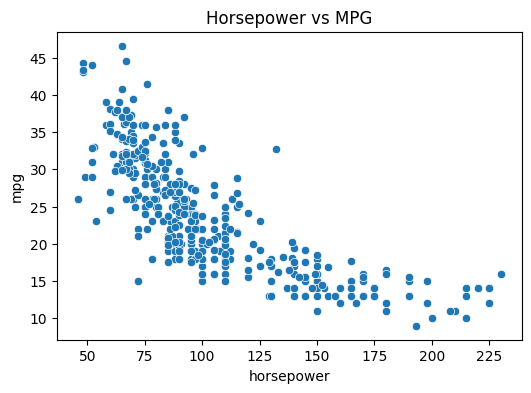

In [4]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='horsepower', y='mpg', data=df)
plt.title("Horsepower vs MPG")
plt.show()

In [5]:
print("Correlation:")
print(df.corr())

Correlation:
            horsepower       mpg
horsepower    1.000000 -0.778427
mpg          -0.778427  1.000000


In [6]:
X = df['horsepower'].values
y = df['mpg'].values

# Add bias term
X_bias = np.c_[np.ones(len(X)), X]

# Normal Equation
w = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

print("Intercept:", w[0])
print("Slope:", w[1])

Intercept: 39.9358610211705
Slope: -0.15784473335365387


In [7]:
y_pred = X_bias @ w

In [8]:
residuals = y - y_pred

SSE = np.sum(residuals**2)
MSE = np.mean(residuals**2)

SST = np.sum((y - np.mean(y))**2)
R2 = 1 - (SSE/SST)

print("SSE =", SSE)
print("MSE =", MSE)
print("R² =", R2)

SSE = 9385.915871932419
MSE = 23.943662938603108
R² = 0.6059482578894348


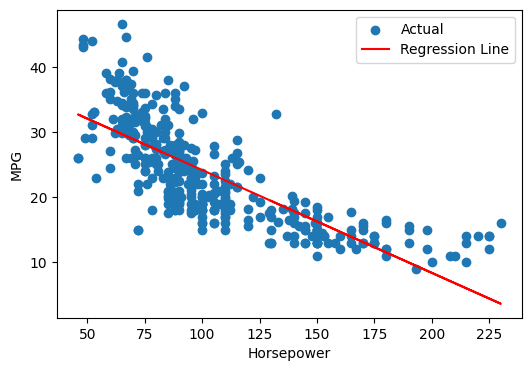

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(X, y, label='Actual')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.legend()
plt.show()

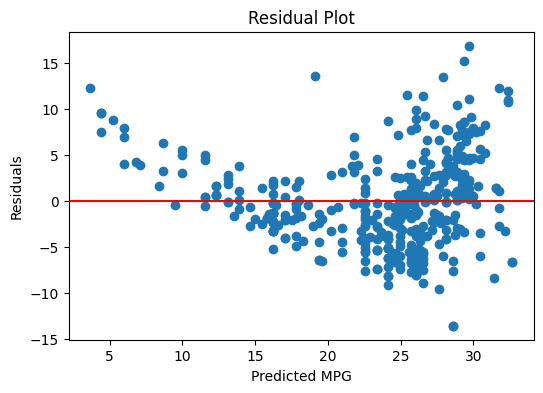

In [10]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Conclusion
The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
